<a href="https://colab.research.google.com/github/glasslego/ml-deep-learning-study/blob/main/src/deep_learning_example/01_titanic_survival_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/glasslego/ml-deep-learning-study/blob/main/src/deep_learning_example/01_titanic_survival_prediction.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩에서 실행하기</a>
  </td>
</table>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Simple neural network implementation without PyTorch
class SimpleNN:
    def __init__(self, input_size, hidden_sizes, output_size):
        self.layers = []
        sizes = [input_size] + hidden_sizes + [output_size]

        # Initialize weights and biases
        for i in range(len(sizes) - 1):
            self.layers.append({
                'W': np.random.randn(sizes[i], sizes[i+1]) * np.sqrt(2.0 / sizes[i]),
                'b': np.zeros((1, sizes[i+1])),
                'vW': np.zeros((sizes[i], sizes[i+1])),
                'vb': np.zeros((1, sizes[i+1]))
            })

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(float)

    def forward(self, X, training=True):
        self.activations = [X]
        self.z_values = []

        for i, layer in enumerate(self.layers):
            z = np.dot(self.activations[-1], layer['W']) + layer['b']
            self.z_values.append(z)

            # Use ReLU for hidden layers, sigmoid for output
            if i < len(self.layers) - 1:
                a = self.relu(z)
                if training:
                    # Dropout
                    mask = np.random.binomial(1, 0.8, size=a.shape) / 0.8
                    a *= mask
            else:
                a = self.sigmoid(z)

            self.activations.append(a)

        return self.activations[-1]

    def backward(self, X, y, lr=0.001, momentum=0.9, weight_decay=1e-5):
        m = X.shape[0]

        # Output layer error
        delta = self.activations[-1] - y

        # Backpropagate
        for i in range(len(self.layers) - 1, -1, -1):
            # Gradients
            dW = np.dot(self.activations[i].T, delta) / m
            db = np.sum(delta, axis=0, keepdims=True) / m

            # L2 regularization
            dW += weight_decay * self.layers[i]['W']

            # Momentum update
            self.layers[i]['vW'] = momentum * self.layers[i]['vW'] - lr * dW
            self.layers[i]['vb'] = momentum * self.layers[i]['vb'] - lr * db

            self.layers[i]['W'] += self.layers[i]['vW']
            self.layers[i]['b'] += self.layers[i]['vb']

            # Propagate error to previous layer
            if i > 0:
                delta = np.dot(delta, self.layers[i]['W'].T)
                delta *= self.relu_derivative(self.activations[i])

    def train(self, X, y, X_val, y_val, epochs=100, batch_size=32, lr=0.001, patience=15):
        history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
        best_val_loss = float('inf')
        patience_counter = 0

        for epoch in range(epochs):
            # Shuffle training data
            indices = np.random.permutation(len(X))
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Mini-batch training
            for i in range(0, len(X), batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                self.forward(X_batch, training=True)
                self.backward(X_batch, y_batch, lr=lr)

            # Evaluate on training set
            y_pred_train = self.forward(X, training=False)
            train_loss = -np.mean(y * np.log(y_pred_train + 1e-7) + (1 - y) * np.log(1 - y_pred_train + 1e-7))
            train_acc = np.mean((y_pred_train > 0.5) == y)

            # Evaluate on validation set
            y_pred_val = self.forward(X_val, training=False)
            val_loss = -np.mean(y_val * np.log(y_pred_val + 1e-7) + (1 - y_val) * np.log(1 - y_pred_val + 1e-7))
            val_acc = np.mean((y_pred_val > 0.5) == y_val)

            history['loss'].append(train_loss)
            history['acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch+1}")
                    break

            # Learning rate decay
            if patience_counter > 5:
                lr *= 0.5
                patience_counter = 0

        return history

    def predict(self, X):
        return self.forward(X, training=False)


# 📊 Titanic Survival Prediction with Simple Neural Network


In [4]:
# Load and prepare data (you'll need to adjust this based on your actual data)
# Assuming you have preprocessed features
# For demonstration, creating sample data structure

def prepare_titanic_data():
    """
    Prepare Titanic dataset
    """
    # Load the dataset
    # Assuming the dataset is in a file named 'titanic.csv' in the content directory
    try:
        df = pd.read_csv('/content/titanic.csv')
    except FileNotFoundError:
        print("Error: 'titanic.csv' not found. Please upload the file.")
        # Create a dummy dataframe for demonstration if the file is not found
        data = {'PassengerId': range(1, 892), 'Survived': np.random.randint(0, 2, 891),
                'Pclass': np.random.randint(1, 4, 891), 'Sex': np.random.choice(['male', 'female'], 891),
                'Age': np.random.rand(891) * 80, 'SibSp': np.random.randint(0, 5, 891),
                'Parch': np.random.randint(0, 5, 891), 'Fare': np.random.rand(891) * 500,
                'Embarked': np.random.choice(['C', 'Q', 'S', np.nan], 891)}
        df = pd.DataFrame(data)
        print("Using dummy data for demonstration.")


    # Simple preprocessing (handle missing values and encode categorical features)
    df['Age'].fillna(df['Age'].median(), inplace=True)
    df['Fare'].fillna(df['Fare'].median(), inplace=True)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

    # Define features (X) and target (y)
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
    X = df[features].values
    y = df['Survived'].values

    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    return X_train, X_val, y_train, y_val

In [5]:
# Training multiple models
models_config = {
    'Simple': [64],
    'Medium': [128, 64],
    'Deep': [128, 64, 32]
}

results = {}

# Assuming you have X_train_split, y_train_split, X_val_split, y_val_split defined
# Replace this with your actual data preparation

# Prepare the data
X_train_split, X_val_split, y_train_split, y_val_split = prepare_titanic_data()

print("🚀 신경망 모델 훈련 시작\n")

for name, hidden_sizes in models_config.items():
    print(f"\n📊 {name} 모델 훈련 중...")

    # Create model (adjust input_size based on your features)
    input_size = X_train_split.shape[1]  # Number of features
    model = SimpleNN(input_size, hidden_sizes, output_size=1)

    # Train model
    history = model.train(
        X_train_split, y_train_split.reshape(-1, 1),
        X_val_split, y_val_split.reshape(-1, 1),
        epochs=100, batch_size=32, lr=0.001, patience=15
    )

    results[name] = {
        'model': model,
        'history': history,
        'best_val_acc': max(history['val_acc'])
    }

    print(f"✅ {name} 모델 완료 - 최고 검증 정확도: {results[name]['best_val_acc']:.4f}")

print("\n🎉 모든 모델 훈련 완료!")

Error: 'titanic.csv' not found. Please upload the file.
Using dummy data for demonstration.
🚀 신경망 모델 훈련 시작


📊 Simple 모델 훈련 중...
Epoch 10/100 - Loss: 0.6838, Acc: 0.5562, Val Loss: 0.6991, Val Acc: 0.5531
Epoch 20/100 - Loss: 0.6768, Acc: 0.5660, Val Loss: 0.6929, Val Acc: 0.5307
Epoch 30/100 - Loss: 0.6747, Acc: 0.5730, Val Loss: 0.6914, Val Acc: 0.5251
Epoch 40/100 - Loss: 0.6739, Acc: 0.5772, Val Loss: 0.6915, Val Acc: 0.5196
Epoch 50/100 - Loss: 0.6737, Acc: 0.5772, Val Loss: 0.6915, Val Acc: 0.5140
Epoch 60/100 - Loss: 0.6736, Acc: 0.5772, Val Loss: 0.6914, Val Acc: 0.5140
Epoch 70/100 - Loss: 0.6736, Acc: 0.5787, Val Loss: 0.6913, Val Acc: 0.5140
Epoch 80/100 - Loss: 0.6736, Acc: 0.5787, Val Loss: 0.6913, Val Acc: 0.5140
Epoch 90/100 - Loss: 0.6736, Acc: 0.5787, Val Loss: 0.6913, Val Acc: 0.5140
Epoch 100/100 - Loss: 0.6736, Acc: 0.5787, Val Loss: 0.6913, Val Acc: 0.5140
✅ Simple 모델 완료 - 최고 검증 정확도: 0.5922

📊 Medium 모델 훈련 중...
Epoch 10/100 - Loss: 0.6855, Acc: 0.5829, Val Loss: 0.

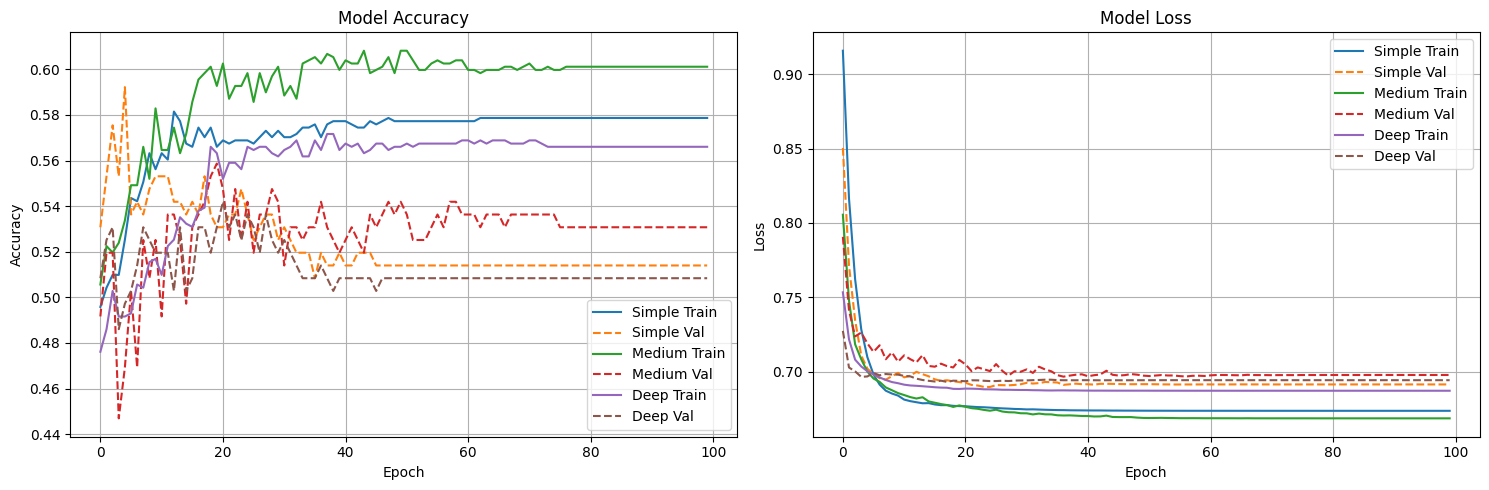

In [6]:
# Visualize results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, result in results.items():
    history = result['history']

    axes[0].plot(history['acc'], label=f'{name} Train')
    axes[0].plot(history['val_acc'], label=f'{name} Val', linestyle='--')

    axes[1].plot(history['loss'], label=f'{name} Train')
    axes[1].plot(history['val_loss'], label=f'{name} Val', linestyle='--')

axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
